In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\Rohan Landge\Downloads\winequality_main.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [4]:
x=df.drop('quality', axis=1)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x= scaler.fit_transform(x)

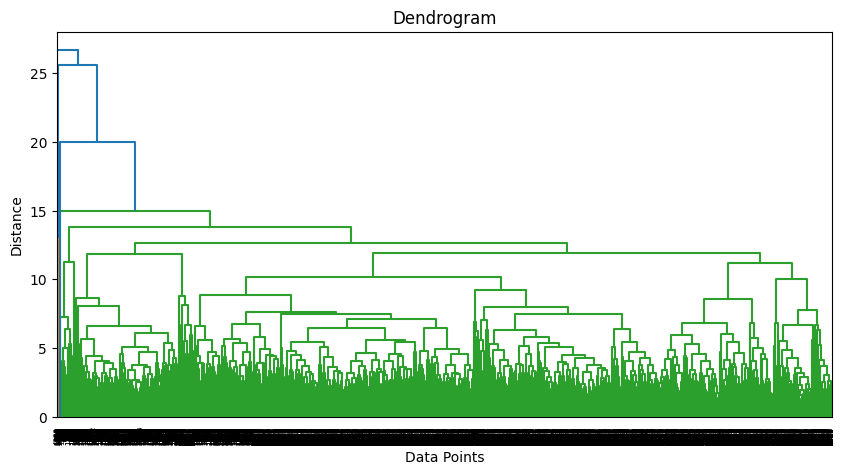

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(x, method='complete')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [7]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=3, linkage='complete')
df['cluster'] = model.fit_predict(x)

In [8]:
from sklearn.metrics import silhouette_score
score = silhouette_score(x, df['cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.6310944556026973


In [9]:
print("\nAverage Quality per Cluster:")
print(df.groupby('cluster')['quality'].mean())

print("\nCluster Count:")
print(df['cluster'].value_counts())


Average Quality per Cluster:
cluster
0    5.820303
1    6.000000
2    5.291667
Name: quality, dtype: float64

Cluster Count:
cluster
0    6472
2      24
1       1
Name: count, dtype: int64


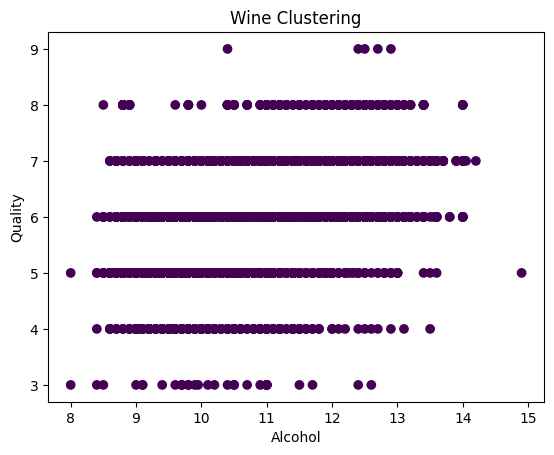

In [10]:
plt.scatter(df['alcohol'], df['quality'], c=df['cluster'])
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Wine Clustering")
plt.show()